In [1]:
Base.active_project()


"/home/jonas/Documents/project/JaxIntro/HMC_enzyme/Project.toml"

# Example HMC Notebook

In this Notebook I want to show how a (very extremely basic and bad) implementation of HMC looks like, and why we generally care about it, at all.

In [2]:
using Distributions, Plots, StatsPlots, Measures, MCMCChains

The above Packages are for Convenience only, in order to start our implementation we really only need `random`. But since we want to have plots, and also want to not reeimplement a Gaussian Random Distribution for the 10k'th time, we import packages dealing with this for us.

Today, let us show what HMC does on the example of a 2d Multi variate Gaussian.

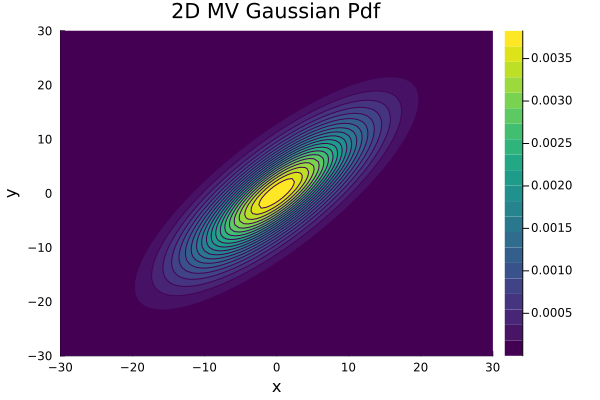

In [3]:
target_distribution = MultivariateNormal([0.0, 0.0], [16.0 14; 14 19].*4)
x = y = range(-30, 30.,100)
p = contour(x,y, (x,y)-> pdf(target_distribution, [x,y]),
            xlims=(minimum(x), maximum(x)), ylims=(minimum(y), maximum(y)), levels=20, color=:viridis,
            fill=true,
            right_margin=10mm,)
xlabel!(p,"x")
ylabel!(p,"y")
title!(p,"2D MV Gaussian Pdf")



The Main Issue with MCMC methods is the correlation of the samples. If we just use a random position close to our initial condition, then the two are strongly correlated; no suprises here, as we only move a small distance. However, with MCMC we want to sample from the whole target distribution; and not only that, we typically want _*independent*_ samples.

Remember, that in the Metropolis Monte Carlo method, it does not *really* matter how we obtain our proposal for the next iterations, as long as we can guarantee detailed balance. HMC is a method to obtain a larger distance between our intial condition and the next step, while maintaining the detailed Balance. The idea here is, that a Hamiltonian gives rise to a _invertible_ trajectory. That is nice, since then given an initial and a final state, the forwards and backwards trajectory are equally likely, and the only thing we need to worry about are the log probabilietes at the initial and final position, giving us the Metropolis-Hastings-Correction-Term $\alpha$.

This does however require that we are faithfull in our Hamiltonian Integration, meaning we need a good (symplectic see https://en.wikipedia.org/wiki/Symplectic_integrator) solver. The Leapfrog algorithm used below is a very simple form of an symplectic (=Energy conserving) Integrator.

In [4]:
using Enzyme
"""
    Single Step following the Leapfrog integrator, conserving the Energy of the system.
"""
function frogleap_step(q,p, E, K, eta)
    p_half = p - eta/2 * gradient(Reverse, E, q)[1]
    q = q + eta * gradient(Reverse, K, p_half)[1]
    p = p_half - eta/2 * gradient(Reverse, E, q)[1]
    return q,p
end


"""
Obtain a proposal position q_next and the corresponding acceptance probability α, based upon L steps of the leapfrog integrator, and unit Mass Matrix.
"""
function hamilton_proposal(q, logpdf, L)
    E = x-> -logpdf(x)
    v = randn(length(q))
    q_0, v_0 = q, v
    K = (v) -> v'*v/2 #Mass = 1
    for i in 1:L
        q,p = frogleap_step(q, v, E, K, 0.5)
    end
    alpha = min(1, exp(- (E(q) + K(v)) + (E(q_0) + K(v_0))))
    return q, alpha
end

"""
Obtain a proposal position q_next based upon a random displacement dq~N(0,I), and the corresponding acceptance probability α.
"""
function normal_proposal(q, logpdf, L)
    dq = randn(length(q)) #q ~ N(0,1)
    alpha = exp(logpdf(q+dq) - logpdf(q))
    return q+dq, alpha
end

normal_proposal

Note that in the HMC algorithm the negative log pdf gives rise to a potential: meaning we associate unlikely events with a high energy cost, and have our energy minimum in the mode of our probability.
This is nice, because it means we cannot run too easily into the unlikely regions, (since we can only a distance against the potential corresponding to the (random) kinetic energy we have), and have a high acceptance ratio.

You might have noticed that in both the "normal" and the HMC algorithm we have some free parameters, the variance and the stepnumber, stepsize, and Mass matrix respectively. Choosing good values for these parameters is not trivial and **very** important. There are sophisticated methods to obtain this, and typically they are dynamically chosen with a certain target acceptance rate in mind. One such example for the HMC algorithm is the NUTS sampler algorithm with hyperparameter estimation, which among other stuff adjusts the parameters during the burn-in period.


In [ ]:
hamilton_proposal([0.0,0.0], x->logpdf(target_distribution, x), 5)

UndefVarError: UndefVarError: `Hamilton_proposal` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [6]:
normal_proposal([0.0,0.0], x->pdf(target_distribution, x), 5)

([1.0809846027214316, -0.4312565113936701], 0.9998342936342576)

In [7]:
function MCMC(q, logpdf, proposal_function, L, N)
    chain = zeros(N, length(q))
    i = 1
    while i<=N
        q_new, alpha = proposal_function(q, logpdf, L)
        if rand() < alpha
            q = q_new
            chain[i,:] .= q
            i +=1
        end
    end
    return chain
end

MCMC (generic function with 1 method)

In [8]:
q0 = [-2., -2.]
lpf = x->logpdf(target_distribution, x)
normal_traj = MCMC(q0, lpf, normal_proposal, 5, 10000);
hmc_traj = MCMC(q0, lpf, hamilton_proposal, 15, 10000);

┌ Warning: TODO forward zero-set of memorycopy used memset rather than runtime type 
│ Caused by:
│ Stacktrace:
│   [1] copy
│     @ ./array.jl:350
│   [2] unaliascopy
│     @ ./abstractarray.jl:1516
│   [3] unalias
│     @ ./abstractarray.jl:1500
│   [4] broadcast_unalias
│     @ ./broadcast.jl:946
│   [5] preprocess
│     @ ./broadcast.jl:953
│   [6] preprocess_args
│     @ ./broadcast.jl:956
│   [7] preprocess_args
│     @ ./broadcast.jl:955
│   [8] preprocess
│     @ ./broadcast.jl:952
│   [9] override_bc_copyto!
│     @ ~/.julia/packages/Enzyme/QsaeA/src/compiler/interpreter.jl:798
│  [10] copyto!
│     @ ./broadcast.jl:925
│  [11] override_bc_materialize
│     @ ~/.julia/packages/Enzyme/QsaeA/src/compiler/interpreter.jl:854
│  [12] sqmahal
│     @ ~/.julia/packages/Distributions/tQhJE/src/multivariate/mvnormal.jl:267
└ @ Enzyme.Compiler ~/.julia/packages/GPUCompiler/AQezv/src/utils.jl:59


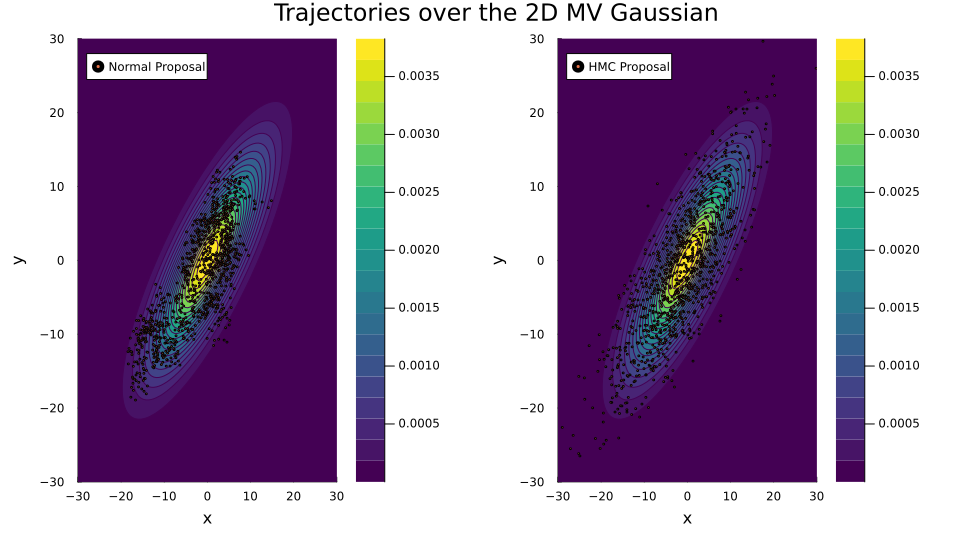

In [9]:

p1 = contour(x,y, (x,y)-> pdf(target_distribution, [x,y]),
            xlims=(minimum(x), maximum(x)), ylims=(minimum(y), maximum(y)),
            levels=20, color=:viridis,
            fill=true,
            right_margin=10mm,)
xlabel!(p1,"x")
ylabel!(p1,"y")
scatter!(p1, normal_traj[1:1000,1], normal_traj[:,2], label="Normal Proposal", markersize=1)

p2 = contour(x,y, (x,y)-> pdf(target_distribution, [x,y]),
            xlims=(minimum(x), maximum(x)), ylims=(minimum(y), maximum(y)),
            levels=20, color=:viridis,
            fill=true,
            right_margin=10mm,)
xlabel!(p2,"x")
ylabel!(p2,"y")
scatter!(p2, hmc_traj[1:1000,1], hmc_traj[:,2], label="HMC Proposal", markersize=1)
plot(p1,p2, size=(1600,900).*0.6, plot_title="Trajectories over the 2D MV Gaussian",  bottommargin=5mm, leftmargin=5mm)

In [10]:
using MCMCChains

Great! The plots show us that the HMC covers our target distribtion more nicely (for the first 1000 samples). Well, considering the eye measure... There are of course more objective measures. The package MCMCChains can calculate some for us: ESS (effective sampling size, #amount of "independent" samples we can obtain form the chain), rhat (which is a heuristic and "measures" if our chain is converged, typically we say it is not converged if rhat > 1.01; however a small rhat is no guarantee of convergence), and most importently the Autocorrelation length. This length gives us the average amount of steps we need to wait until a new sample is "independent".

In [11]:
normal_chain = MCMCChains.Chains(normal_traj) 
normal_chain |> summarize


  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

     param_1   -0.4442    7.8485    1.3699    33.0505    44.0836    1.0484     ⋯
     param_2   -0.9566    9.4577    1.6932    31.3160    56.1960    1.0622     ⋯
                                                                1 column omitted


In [12]:
hmc_chain = Chains(hmc_traj)
summarize(hmc_chain)


  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

     param_1   -0.0625    7.9077    0.2372   1111.3839   1981.8577    1.0003   ⋯
     param_2   -0.0166    8.7454    0.2724   1027.4475   1823.2613    1.0018   ⋯
                                                                1 column omitted


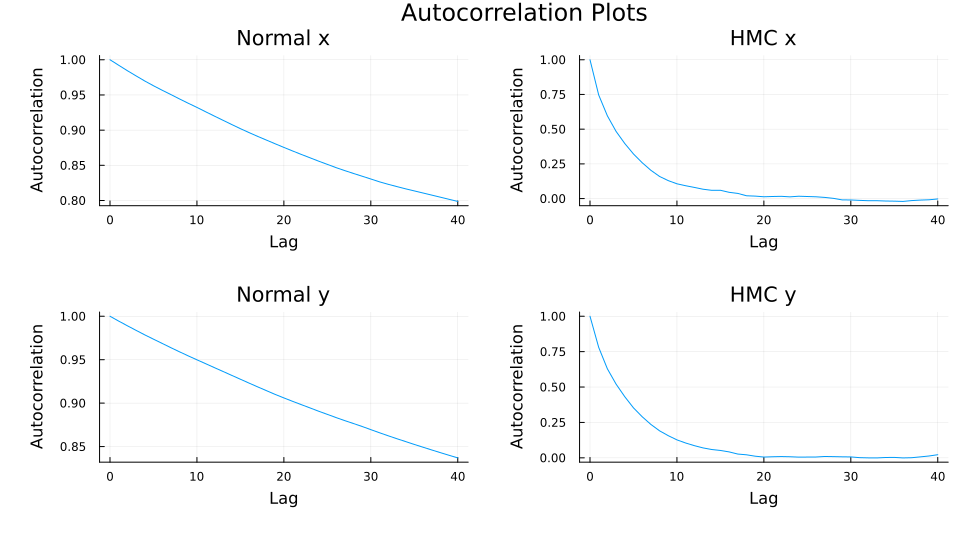

In [13]:
ac1 = autocorplot(normal_chain, titles=["Normal x"  "Normal y"])
ac2 = autocorplot(hmc_chain, titles=["HMC x"  "HMC y"])
plot(ac1, ac2, size = (1600,900).*0.6, leftmargin=10mm, bottommargin=10mm, plot_title="Autocorrelation Plots")

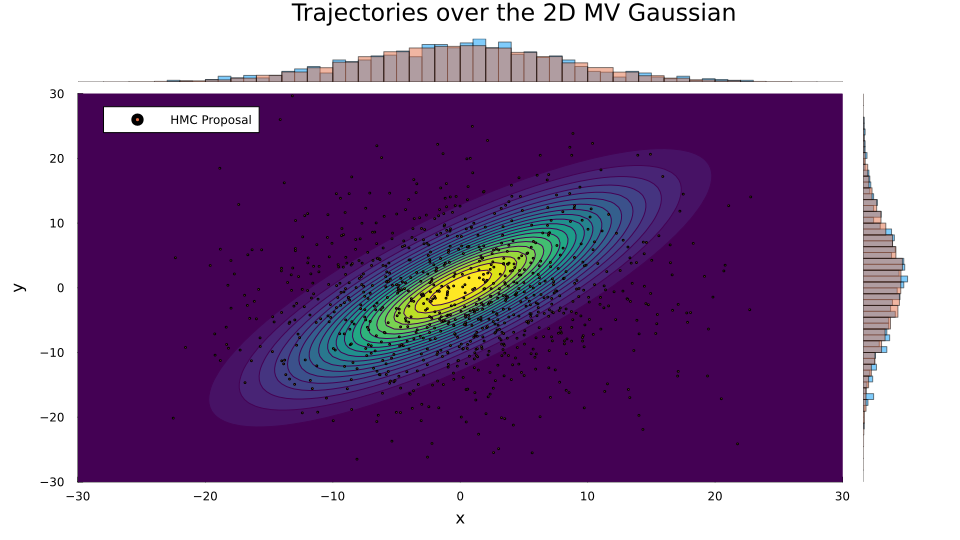

In [14]:
p3 = contour(x,y, (x,y)-> pdf(target_distribution, [x,y]),
            xlims=(minimum(x), maximum(x)), ylims=(minimum(y), maximum(y)),
            levels=20, color=:viridis,
            fill=true, cbar=false, topmargin=0mm)
target_samples = rand(target_distribution, 100000)'

xlabel!(p3,"x")
ylabel!(p3,"y")
scatter!(p3, hmc_traj[1000:10:end,1], hmc_traj[:,2], label="HMC Proposal", markersize=1)
p4 = histogram(hmc_traj[1000:10:end,1], label="", xlims=(minimum(x), maximum(x)), axis=false, grid=false, bins=50, bottommargin=0mm, alpha = 0.5, normalize=true)
histogram!(p4, target_samples[:,1], label="", xlims=(minimum(x), maximum(x)), axis=false, grid=false, bins=50, bottommargin=0mm, alpha = 0.5, normalize=true)

p5 = histogram(hmc_traj[1000:10:end,2], permute=(:x, :y), ywiden=false, xwiden=false, ylims=(0, 0.1), bins=50, label="", axis=false, grid=false, normalize=true, alpha = 0.5)
histogram!(p5, target_samples[1:10:end,2], permute=(:x, :y), ywiden=false, xwiden=false, ylims=(0, 0.1), bins=50, label="", axis=false, grid=false, normalize=true, alpha=0.5)

plot(layout=[@layout [a{0.1h} _; c{0.9h} d{0.1w}]], p4, p3, p5, size=(1600,900).*0.6, plot_title="Trajectories over the 2D MV Gaussian",
    leftmargin=[5mm 5mm -9mm], bottommargin=[-9mm 5mm 5mm])

Of course if we want to use HMC in action, we would do none of these things manually. There a plenty of good implementation of HMC and similar algorithms. Here, we want to show how to use HMC for Bayesian Inference using Turing.
Note that HMC is a form if **exakt** inference, and typically much much much [...] much slower than VI.

In [ ]:
using Statistics, LinearAlgebra, Plots, StatsPlots, Turing, ForwardDiff

# Data generation
function generate_synthetic_data(;w₀::Float64=0.5, w₁::Float64=1.5, noise_std::Float64=2.0)
    x = randn(1000) .* 40
    y = @. w₀ + w₁*x + noise_std*randn()
    return x, y, (w₀, w₁)
end

# MLE estimation
function fit_mle(x::Vector{<:Real}, y::Vector{<:Real})
    x_centered = x .- mean(x)
    y_centered = y .- mean(y)
    w₁ = pinv(x_centered) * y_centered
    w₀ = mean(y) - mean(x) * w₁
    
    ŷ = @. w₁*x + w₀
    N = length(y)
    σ² = 1/(N-2) * sum((y .- ŷ).^2)
    
    return (w₀=w₀, w₁=w₁, σ²=σ²)
end

# Bayesian model
@model function bayesian_linear_regression(x, y, n)
    σ² ~ InverseGamma(0.01, 0.01)
    w_0 ~ Uniform(-5, 5)
    w_1 ~ Uniform(-5, 5)
    for i in 1:n
        μ = w_0 + w_1 * x[i]
        y[i] ~ Normal(μ, sqrt(σ²))
    end
end

# Add MAP estimation function
function fit_map(chain)
    # Find the maximum a posteriori estimates
    s = summarize(chain, median)
    w₀_map = s[:w_0, :median]
    w₁_map = s[:w_1, :median]
    σ²_map = s[:σ², :median]
    
    return (w₀=w₀_map, w₁=w₁_map, σ²=σ²_map)
end

# Plotting functions
function plot_results(x, y, true_params, mle_params, map_params, bayes_results)
    x_range = range(minimum(x), maximum(x), 100)
    
    # Main plot
    p = scatter(x, y, 
        label="Data (w₀=$(round(true_params[1], digits=2)), w₁=$(round(true_params[2], digits=2)))",
        xlabel="x", ylabel="y", dpi=300)
    
    # Add MLE fit
    ŷ_mle = @. mle_params.w₁ * x_range + mle_params.w₀
    plot!(p, x_range, ŷ_mle, 
        label="MLE: w₀=$(round(mle_params.w₀, digits=2)), w₁=$(round(mle_params.w₁, digits=2)), σ²=$(round(mle_params.σ², digits=2))",
        ribbon=sqrt(mle_params.σ²), fillalpha=0.1)
    
    # Add MAP fit
    ŷ_map = @. map_params.w₁ * x_range + map_params.w₀
    plot!(p, x_range, ŷ_map,
        label="MAP: w₀=$(round(map_params.w₀, digits=2)), w₁=$(round(map_params.w₁, digits=2)), σ²=$(round(map_params.σ², digits=2))",
        ribbon=sqrt(map_params.σ²), fillalpha=0.1)
    
    # Add Bayesian results
    plot!(p, x_range, bayes_results.predicted_mean,
        label="Bayesian: w₀=$(round(bayes_results.w₀, digits=2)), w₁=$(round(bayes_results.w₁, digits=2)), σ²=$(round(bayes_results.σ², digits=2))",
        ribbon=bayes_results.predicted_std, fillalpha=0.1)
    
    # Create inset plot
    inset = (1, bbox(0.6, 0.6, 0.35, 0.35))
    p_inset = scatter!(x,y, inset=inset, subplot=2, label="")
    
    # Copy main plot content for inset with adjusted ranges
    #scatter!(p_inset[2], x, y, label="", markersize=3)
    plot!(p_inset[2], x_range, ŷ_mle, label="", ribbon=sqrt(mle_params.σ²), fillalpha=0.1)
    plot!(p_inset[2], x_range, ŷ_map, label="", ribbon=sqrt(map_params.σ²), fillalpha=0.1)
plot!(p_inset[2], x_range, bayes_results.predicted_mean, label="", 
          ribbon=bayes_results.predicted_std, fillalpha=0.1)
    
    # Set inset range to zoom region
    xlims!(p_inset[2], (111, 113))
    ylims!(p_inset[2], (167.5, 170))  # Adjust these values based on your y-range
    
    # Add inset to main plot

    
    return p
end

# Main execution
function run_analysis(generator, model_fn)
    # Generate data
    x, y, true_params = generator()
    
    # MLE estimation
    mle_params = fit_mle(x, y)
    
    # Bayesian inference
    model = model_fn(x, y, length(y))
    chain = sample(model, NUTS(adtype=AutoForwardDiff()), 1000)
    
    # MAP estimation
    map_params = fit_map(chain)
    
    # Extract Bayesian results
    sums = summarize(chain, mean, std)
    bayes_results = (
        w₀=sums[:w_0, :mean],
        w₁=sums[:w_1, :mean],
        σ²=sums[:σ², :mean],
        predicted_mean=nothing,  # To be filled by prediction
        predicted_std=nothing    # To be filled by prediction
    )
    
    # Generate predictions
    x_range = range(minimum(x), maximum(x), 100)
    pred_model = bayesian_linear_regression(collect(x_range), 
        Vector{Union{Missing, Float64}}(undef, 100), 100)
    post_pred = predict(pred_model, chain)
    pred_sums = summarize(post_pred, mean, std)
    
    bayes_results = merge(bayes_results, 
        (predicted_mean=pred_sums[:,:mean], predicted_std=pred_sums[:,:std]))
    
    # Plotting
    p = plot_results(x, y, true_params, mle_params, map_params, bayes_results)
    #savefig(p, "comparison_mle_map_bayes")
    
    # Additional diagnostics
    corner_plot = corner(chain)
   #savefig(corner_plot, "parameter_distributions")
    
    return mle_params, map_params, bayes_results, p, corner_plot, chain
end


mle, map, bayes, p, cp, chain= run_analysis(generate_synthetic_data, bayesian_linear_regression) 
savefig(p, "comparison_mle_map_bayes_simple")

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.0015625
└ @ Turing.Inference /home/jonas/.julia/packages/Turing/oFGEb/src/mcmc/hmc.jl:213
Sampling   0%|▎                                         |  ETA: 3:19:22
Sampling   1%|▍                                         |  ETA: 1:43:46
Sampling   1%|▋                                         |  ETA: 1:12:30
Sampling   2%|▊                                         |  ETA: 0:58:41
Sampling   2%|█                                         |  ETA: 0:48:33
Sampling   3%|█▏                                        |  ETA: 0:43:04

<img src="comparison_mle_map_bayes.png" style='width: 50%'>

In [16]:
plot(chain)

UndefVarError: UndefVarError: `chain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing IterTools in the current active module Main

In [17]:
function generate_complicated_synthetic_data(;w₀::Float64=0.5, w₁::Float64=1.5, noise_std::Float64=2.0)
    x = randn(1000) .* 40
    w_rand = randn(length(x))*0.5 .+ w₁
    y = @. w₀ + w_rand .*x + noise_std*randn()
    return x, y, (w₀, w₁)
end

@model function more_complicated_model(x, y, n)
    σ² ~ InverseGamma(0.01, 0.01)
    w_0 ~ Uniform(-5, 5)
    w_1 ~ Uniform(-5,5)
    w_1_std ~ InverseGamma(0.01, 0.01)
    m ~ arraydist([Normal(w_1, sqrt(w_1_std)) for i in 1:n])
    for i in 1:n
        μ = w_0 + m[i] * x[i]
        y[i] ~ Normal(μ, sqrt(σ²))
    end
end

mle, map, bayes, p, cp, chain= run_analysis(generate_complicated_synthetic_data, more_complicated_model) 
savefig(p, "comparison_mle_map_bayes_complicated")


Sampling   0%|                                          |  ETA: N/A
Sampling 100%|██████████████████████████████████████████| Time: 0:00:01


MethodError: MethodError: no method matching ADgradient(::Val{:ReverseDiff}, ::LogDensityFunction{DynamicPPL.TypedVarInfo{@NamedTuple{σ²::DynamicPPL.Metadata{Dict{AbstractPPL.VarName{:σ², typeof(identity)}, Int64}, Vector{InverseGamma{Float64}}, Vector{AbstractPPL.VarName{:σ², typeof(identity)}}, Vector{Float64}, Vector{Set{DynamicPPL.Selector}}}, w_0::DynamicPPL.Metadata{Dict{AbstractPPL.VarName{:w_0, typeof(identity)}, Int64}, Vector{Uniform{Float64}}, Vector{AbstractPPL.VarName{:w_0, typeof(identity)}}, Vector{Float64}, Vector{Set{DynamicPPL.Selector}}}, w_1::DynamicPPL.Metadata{Dict{AbstractPPL.VarName{:w_1, typeof(identity)}, Int64}, Vector{Uniform{Float64}}, Vector{AbstractPPL.VarName{:w_1, typeof(identity)}}, Vector{Float64}, Vector{Set{DynamicPPL.Selector}}}, w_1_std::DynamicPPL.Metadata{Dict{AbstractPPL.VarName{:w_1_std, typeof(identity)}, Int64}, Vector{InverseGamma{Float64}}, Vector{AbstractPPL.VarName{:w_1_std, typeof(identity)}}, Vector{Float64}, Vector{Set{DynamicPPL.Sele

In [18]:
plot(chain)

UndefVarError: UndefVarError: `chain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing IterTools in the current active module Main

In [19]:
summarize(chain)

UndefVarError: UndefVarError: `chain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing IterTools in the current active module Main